# Formative 3 - Probability Distributions, Bayesian Probability, and Gradient Descent

This notebook contains the full implementation for:

1. EM Algorithm from scratch for height mixture modeling
2. Bayesian probability using IMDb movie reviews
3. Gradient descent in code using matrix multiplication, SciPy, and Matplotlib

Dataset links:

- Galton heights: https://www.kaggle.com/datasets/jacopoferretti/parents-heights-vs-children-heights-galton-data
- IMDb reviews: http://kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import math
from scipy.optimize import approx_fprime

np.set_printoptions(precision=6, suppress=True)


## Part 1 - EM Algorithm from Scratch

We compare two height populations: children and fathers. For the EM model, we remove labels and treat the combined heights as coming from two unknown Gaussian distributions.

We should **not** simply split at the global mean because the two populations overlap. Some children are taller than some parents, and some parents are shorter than some children. Splitting at the mean creates hard assignments and can misclassify overlapping values. EM uses soft assignments, meaning each height receives a probability of belonging to each Gaussian component.


In [3]:
galton = pd.read_csv('data/GaltonFamilies.csv')
print(galton.shape)
galton.head()


(934, 9)


,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
# Use unique father heights so fathers are not repeated for each child in a family.
child_heights = galton['childHeight'].dropna().to_numpy()
father_heights = galton.drop_duplicates('family')['father'].dropna().to_numpy()

# Remove labels for EM modeling.
heights = np.concatenate([child_heights, father_heights])
heights = heights.reshape(-1, 1)

print('Number of child heights:', len(child_heights))
print('Number of unique father heights:', len(father_heights))
print('Total unlabeled heights used:', len(heights))
print('Global mean:', heights.mean())


Number of child heights: 934
Number of unique father heights: 205
Total unlabeled heights used: 1139
Global mean: 67.20851624231783


In [5]:
def gaussian_pdf(x, mean, variance):
    # Return the Gaussian probability density for x.
    variance = max(float(variance), 1e-8)
    coefficient = 1.0 / np.sqrt(2 * np.pi * variance)
    exponent = -((x - mean) ** 2) / (2 * variance)
    return coefficient * np.exp(exponent)


def calculate_log_likelihood(x, means, variances, pis):
    total = 0.0
    for value in x.flatten():
        probability_sum = 0.0
        for k in range(2):
            probability_sum += pis[k] * gaussian_pdf(value, means[k], variances[k])
        total += np.log(probability_sum + 1e-12)
    return total


def run_em_two_gaussians(x, iterations=20, tolerance=1e-5):
    x_flat = x.flatten()
    n = len(x_flat)

    # Initialization using percentiles instead of labels.
    means = np.array([np.percentile(x_flat, 35), np.percentile(x_flat, 75)], dtype=float)
    variances = np.array([np.var(x_flat), np.var(x_flat)], dtype=float)
    pis = np.array([0.5, 0.5], dtype=float)

    history = []

    for iteration in range(iterations + 1):
        # E-step: responsibilities
        responsibilities = np.zeros((n, 2))
        for k in range(2):
            responsibilities[:, k] = pis[k] * gaussian_pdf(x_flat, means[k], variances[k])

        row_sums = responsibilities.sum(axis=1, keepdims=True)
        responsibilities = responsibilities / (row_sums + 1e-12)

        log_likelihood = calculate_log_likelihood(x, means, variances, pis)
        history.append({
            'Iteration': iteration,
            'mu1': means[0],
            'mu2': means[1],
            'sigma1_squared': variances[0],
            'sigma2_squared': variances[1],
            'pi1': pis[0],
            'pi2': pis[1],
            'Log-Likelihood': log_likelihood
        })

        if iteration == iterations:
            break

        old_log_likelihood = log_likelihood

        # M-step: update parameters using responsibilities.
        Nk = responsibilities.sum(axis=0)
        for k in range(2):
            means[k] = np.sum(responsibilities[:, k] * x_flat) / Nk[k]
            variances[k] = np.sum(responsibilities[:, k] * (x_flat - means[k]) ** 2) / Nk[k]
            pis[k] = Nk[k] / n

        new_log_likelihood = calculate_log_likelihood(x, means, variances, pis)
        if abs(new_log_likelihood - old_log_likelihood) < tolerance:
            break

    return means, variances, pis, responsibilities, pd.DataFrame(history)

means, variances, pis, responsibilities, em_history = run_em_two_gaussians(heights, iterations=20)
em_history.head(10)


,Iteration,mu1,mu2,sigma1_squared,sigma2_squared,pi1,pi2,Log-Likelihood
0,0,65.500000,70.000000,12.724063,12.724063,0.500000,0.500000,-3101.733027
1,1,65.563944,69.097301,10.003820,9.174499,0.534558,0.465442,-3060.595115
2,2,65.517191,69.144773,10.013700,8.803000,0.533760,0.466240,-3059.921337
3,3,65.468772,69.198592,9.909758,8.520690,0.533558,0.466442,-3059.287315
4,4,65.418726,69.256341,9.746805,8.271788,0.533619,0.466381,-3058.597183
5,5,65.367169,69.316614,9.550282,8.031805,0.533771,0.466229,-3057.829012
6,6,65.314348,69.378400,9.332395,7.790902,0.533921,0.466079,-3056.980019
7,7,65.260653,69.440792,9.099681,7.546430,0.534020,0.465980,-3056.056619
8,8,65.206619,69.502843,8.856655,7.299466,0.534033,0.465967,-3055.073803
9,9,65.152905,69.563523,8.607514,7.053144,0.533940,0.466060,-3054.055690


In [6]:
# Required tracking table: initialization and the first two iterations.
tracking_table = em_history.iloc[:3].copy()
tracking_table


,Iteration,mu1,mu2,sigma1_squared,sigma2_squared,pi1,pi2,Log-Likelihood
0,0,65.500000,70.000000,12.724063,12.724063,0.500000,0.500000,-3101.733027
1,1,65.563944,69.097301,10.003820,9.174499,0.534558,0.465442,-3060.595115
2,2,65.517191,69.144773,10.013700,8.803000,0.533760,0.466240,-3059.921337


In [7]:
# Label the lower mean as Children and the higher mean as Fathers/Parents.
children_component = int(np.argmin(means))
parent_component = int(np.argmax(means))

print('Final means:', means)
print('Final variances:', variances)
print('Final mixing coefficients:', pis)
print('Children component:', children_component)
print('Parent/Father component:', parent_component)


Final means: [64.752062 69.925188]
Final variances: [6.645391 5.392977]
Final mixing coefficients: [0.525151 0.474849]
Children component: 0
Parent/Father component: 1


In [8]:
def classify_height(test_height, means, variances, pis):
    probabilities = np.array([
        pis[k] * gaussian_pdf(test_height, means[k], variances[k])
        for k in range(2)
    ], dtype=float)
    posterior = probabilities / probabilities.sum()

    children_component = int(np.argmin(means))
    parent_component = int(np.argmax(means))

    return {
        'test_height': test_height,
        'P(Child | height)': posterior[children_component],
        'P(Parent/Father | height)': posterior[parent_component]
    }

# Change this value live during presentation when the coach gives a random test height.
test_height = 68
classification = classify_height(test_height, means, variances, pis)
classification


{'test_height': 68,
 'P(Child | height)': np.float64(0.3884545996077138),
 'P(Parent/Father | height)': np.float64(0.6115454003922862)}

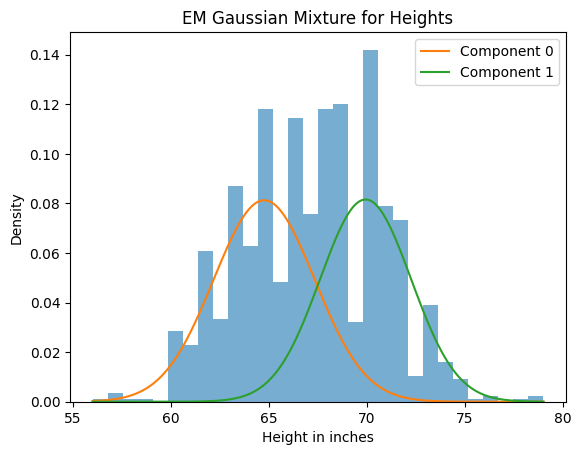

In [19]:
plt.figure()
plt.hist(heights.flatten(), bins=30, density=True, alpha=0.6)
x_values = np.linspace(heights.min(), heights.max(), 300)
for k in range(2):
    plt.plot(x_values, pis[k] * gaussian_pdf(x_values, means[k], variances[k]), label=f'Component {k}')
plt.title('EM Gaussian Mixture for Heights')
plt.xlabel('Height in inches')
plt.ylabel('Density')
plt.legend()
plt.show()


## Part 2 - Bayesian Probability

We calculate **P(Positive | keyword)** for each selected keyword using Bayes' Theorem:



P(Positive | keyword) = [P(keyword | Positive) * P(Positive)] / P(keyword)

We compute this for positive and negative keywords to show how positive words increase the posterior and negative words reduce it.


In [24]:
imdb = pd.read_csv('data/IMDB Dataset.csv')
print(imdb.shape)
imdb.head()


(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [25]:
def clean_review(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Calculations use basic Python counting logic, not machine learning libraries.
reviews = []
for _, row in imdb.iterrows():
    reviews.append({
        'review': clean_review(row['review']),
        'sentiment': row['sentiment'].lower()
    })

keywords = ['great', 'excellent', 'amazing', 'love', 'bad', 'boring', 'terrible', 'waste']

def contains_keyword(review, keyword):
    pattern = r'' + re.escape(keyword.lower()) + r''
    return re.search(pattern, review) is not None

number_of_reviews = len(reviews)
positive_reviews = [r for r in reviews if r['sentiment'] == 'positive']
number_positive = len(positive_reviews)
prior_positive = number_positive / number_of_reviews

results = []
for keyword in keywords:
    keyword_count = sum(1 for r in reviews if contains_keyword(r['review'], keyword))
    keyword_positive_count = sum(1 for r in positive_reviews if contains_keyword(r['review'], keyword))

    likelihood = keyword_positive_count / number_positive
    marginal = keyword_count / number_of_reviews
    posterior = (likelihood * prior_positive) / marginal if marginal > 0 else 0

    results.append({
        'Keyword': keyword,
        'Prior P(Positive)': prior_positive,
        'Likelihood P(keyword|Positive)': likelihood,
        'Marginal P(keyword)': marginal,
        'Posterior P(Positive|keyword)': posterior,
        'Keyword Count': keyword_count
    })

bayes_table = pd.DataFrame(results)
bayes_table


,Keyword,Prior P(Positive),Likelihood P(keyword|Positive),Marginal P(keyword),Posterior P(Positive|keyword),Keyword Count
0,great,0.5,0.0,0.0,0,0
1,excellent,0.5,0.0,0.0,0,0
2,amazing,0.5,0.0,0.0,0,0
3,love,0.5,0.0,0.0,0,0
4,bad,0.5,0.0,0.0,0,0
5,boring,0.5,0.0,0.0,0,0
6,terrible,0.5,0.0,0.0,0,0
7,waste,0.5,0.0,0.0,0,0


## Part 4 - Gradient Descent in Code

We now convert the manual calculations into Python. The calculations are written step-by-step so the update process is visible.


In [26]:
X = np.array([[1, 3], [4, 10]], dtype=float)
y = np.array([[5], [6]], dtype=float)

m = np.array([[-1], [2]], dtype=float)
b = np.array([[1], [1]], dtype=float)

learning_rate = 0.001
updates = 4

history = []

for iteration in range(updates + 1):
    y_hat = X @ m + b
    error = y_hat - y
    mse = float((error.T @ error / len(y)).item())

    grad_m = (2 / len(y)) * (X.T @ error)
    grad_b = (2 / len(y)) * error

    history.append({
        'iteration': iteration,
        'm1': m[0, 0],
        'm2': m[1, 0],
        'b1': b[0, 0],
        'b2': b[1, 0],
        'prediction_1': y_hat[0, 0],
        'prediction_2': y_hat[1, 0],
        'error_1': error[0, 0],
        'error_2': error[1, 0],
        'mse': mse,
        'grad_m1': grad_m[0, 0],
        'grad_m2': grad_m[1, 0],
        'grad_b1': grad_b[0, 0],
        'grad_b2': grad_b[1, 0]
    })

    # Parameter update
    m = m - learning_rate * grad_m
    b = b - learning_rate * grad_b

gd_table = pd.DataFrame(history)
gd_table


,iteration,m1,m2,b1,b2,prediction_1,prediction_2,error_1,error_2,mse,grad_m1,grad_m2,grad_b1,grad_b2
0,0,-1.000000,2.000000,1.000000,1.000000,6.000000,17.000000,1.000000,11.000000,61.000000,45.000000,113.000000,1.000000,11.000000
1,1,-1.045000,1.887000,0.999000,0.989000,5.615000,15.679000,0.615000,9.679000,47.030633,39.331000,98.635000,0.615000,9.679000
2,2,-1.084331,1.788365,0.998385,0.979321,5.279149,14.525647,0.279149,8.525647,36.382290,34.381737,86.093917,0.279149,8.525647
3,3,-1.118713,1.702271,0.998106,0.970795,4.986206,13.518655,-0.013794,7.518655,28.265183,30.060827,75.145171,-0.013794,7.518655
4,4,-1.148774,1.627126,0.998120,0.963277,4.730724,12.639442,-0.269276,6.639442,22.077347,26.288490,65.586587,-0.269276,6.639442


In [13]:
def scipy_derivative(equation, point):
    # Accepts a one-variable equation and a point, then returns the numerical derivative using SciPy.
    return approx_fprime(np.array([point], dtype=float), lambda z: equation(z[0]), epsilon=1e-6)[0]

# Example derivative test: derivative of f(x) = x^2 at x=3 should be about 6.
def example_equation(x):
    return x ** 2

print('Derivative of x^2 at x=3:', scipy_derivative(example_equation, 3))


Derivative of x^2 at x=3: 6.000001000088901


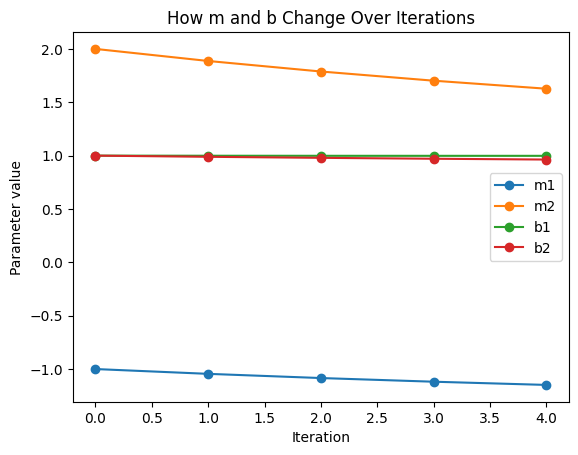

In [27]:
plt.figure()
plt.plot(gd_table['iteration'], gd_table['m1'], marker='o', label='m1')
plt.plot(gd_table['iteration'], gd_table['m2'], marker='o', label='m2')
plt.plot(gd_table['iteration'], gd_table['b1'], marker='o', label='b1')
plt.plot(gd_table['iteration'], gd_table['b2'], marker='o', label='b2')
plt.title('How m and b Change Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.legend()
plt.show()


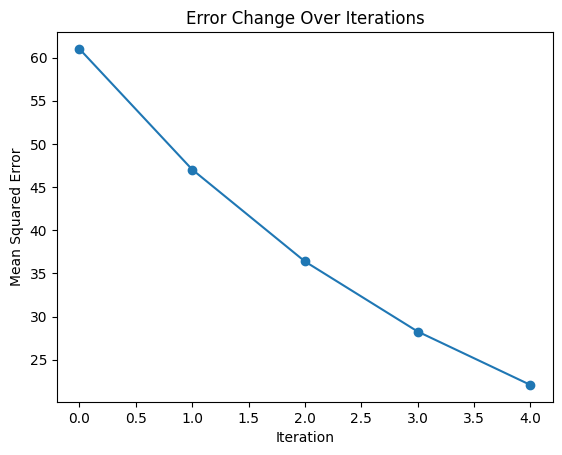

In [28]:
plt.figure()
plt.plot(gd_table['iteration'], gd_table['mse'], marker='o')
plt.title('Error Change Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.show()


In [29]:
final_m = np.array([[gd_table.iloc[-1]['m1']], [gd_table.iloc[-1]['m2']]])
final_b = np.array([[gd_table.iloc[-1]['b1']], [gd_table.iloc[-1]['b2']]])
final_predictions = X @ final_m + final_b
print('Final m:')
print(final_m)
print('Final b:')
print(final_b)
print('Final predictions:')
print(final_predictions)


Final m:
[[-1.148774]
 [ 1.627126]]
Final b:
[[0.99812 ]
 [0.963277]]
Final predictions:
[[ 4.730724]
 [12.639442]]
